In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset, RandomSampler
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

W0418 13:46:54.782000 11936 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
# Initialize tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased', do_lower_case=True)

# Function to save model checkpoints
def save_model(model, tokenizer, output_dir, epoch):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)
    print(f"Model saved at epoch {epoch+1} to {output_dir}")
def train_model(model, train_dataloader, optimizer, device, epoch, num_epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    progress_bar = tqdm(
        train_dataloader,
        desc=f"Epoch {epoch + 1}/{num_epochs}",
        leave=True
    )

    for batch in progress_bar:
        batch_input_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels = batch[2].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            labels=batch_labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item()
        total_correct += (preds == batch_labels).sum().item()
        total_samples += batch_labels.size(0)

        avg_loss = total_loss / (progress_bar.n + 1)
        avg_acc = total_correct / total_samples

        progress_bar.set_postfix(
            loss=f"{avg_loss:.4f}",
            acc=f"{avg_acc:.4f}"
        )

    return avg_loss, avg_acc


def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0

    progress_bar = tqdm(dataloader, desc="Evaluating", leave=True)

    with torch.no_grad():
        for batch in progress_bar:
            batch_input_ids = batch[0].to(device)
            batch_attention_mask = batch[1].to(device)
            batch_labels = batch[2].to(device)

            outputs = model(
                input_ids=batch_input_ids,
                attention_mask=batch_attention_mask,
                labels=batch_labels
            )

            loss = outputs.loss
            logits = outputs.logits

            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

            avg_loss = total_loss / (progress_bar.n + 1)
            progress_bar.set_postfix(loss=f"{avg_loss:.4f}")

    accuracy = accuracy_score(all_labels, all_preds)
    avg_loss = total_loss / len(dataloader)

    return avg_loss, accuracy, all_preds, all_labels



# Function to tokenize text data
def tokenize_texts(texts, labels, max_len=128):
    encodings = tokenizer.batch_encode_plus(
        list(texts),
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = encodings['input_ids']
    attention_masks = encodings['attention_mask']
    labels = torch.tensor(labels)

    return input_ids, attention_masks, labels


'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 67439589-b36b-45f2-8931-8a1698237bfa)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: a1d6c042-55e5-4924-b5e6-a0e40a2a0aaf)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json
Retrying in 2s [Retry 2/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 897f2df3-724c-446d-b4a2-52a66020acec)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer

In [3]:
# Main training loop with early stopping
def train_with_early_stopping(model, train_dataloader, val_dataloader, optimizer, device, num_epochs=3, patience=1):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    best_val_accuracy = 0
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        
        # Train
        train_loss, train_acc = train_model(model, train_dataloader, optimizer, device, epoch, num_epochs)
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        
        # Validate
        val_loss, val_acc, _, _ = evaluate_model(model, val_dataloader, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        # Save best model
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            epochs_no_improve = 0
            save_model(model, tokenizer, 'DistilBERT_model', epoch)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping after {epoch + 1} epochs!")
                break
    
    return train_losses, train_accuracies, val_losses, val_accuracies

# Load your data
df = pd.read_csv("Tweets.csv")
X = df['text'].values
y = df['target'].values

# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Tokenize data
train_input_ids, train_attention_masks, train_labels = tokenize_texts(X_train, y_train)
val_input_ids, val_attention_masks, val_labels = tokenize_texts(X_val, y_val)
test_input_ids, test_attention_masks, test_labels = tokenize_texts(X_test, y_test)

# Create DataLoaders
batch_size = 16
train_data = TensorDataset(train_input_ids, train_attention_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(val_input_ids, val_attention_masks, val_labels)
val_dataloader = DataLoader(val_data, batch_size=batch_size)

test_data = TensorDataset(test_input_ids, test_attention_masks, test_labels)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
).to(device)

# Set up optimizer
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

# Train with early stopping
train_losses, train_accuracies, val_losses, val_accuracies = train_with_early_stopping(
    model, train_dataloader, val_dataloader, optimizer, device, num_epochs=4, patience=1
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

Epoch 1/4


100%|███████████████████████████████████████████████████████| 1986/1986 [00:00<00:00, 662469.20it/s]


Epoch 1/4: 100%|█████████████████████████████████████████████████████| 1986/1986 [2:29:05<00:00,  4.50s/it, acc=0.7984, loss=0.4528]


100%|█████████████████████████████████████████████████████████████████████| 426/426 [00:00<?, ?it/s]


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 426/426 [06:50<00:00,  1.04it/s, loss=0.4026]
Train Loss: 0.4528 | Train Acc: 0.7984
Val Loss: 0.4026 | Val Acc: 0.8203
Model saved at epoch 1 to DistilBERT_model

Epoch 2/4


...

Evaluating: 100%|████████████████████████████████████████████████████████████████████| 426/426 [07:52<00:00,  1.11s/it, loss=0.2953]
Train Loss: 0.2614 | Train Acc: 0.8896
Val Loss: 0.2953 | Val Acc: 0.8500
Model saved at epoch 3 to DistilBERT_model

Epoch 4/4


100%|██████████████████████████████████████████████████████| 1986/1986 [00:00<00:00, 1380491.84it/s]


Epoch 4/4: 100%|█████████████████████████████████████████████████████| 1986/1986 [2:24:52<00:00,  4.38s/it, acc=0.9072, loss=0.2289]


100%|█████████████████████████████████████████████████████████| 426/426 [00:00<00:00, 424512.59it/s]

Evaluating: 100%|████████████████████████████████████████████████████████████████████| 426/426 [10:57<00:00,  1.54s/it, loss=0.3097]
Train Loss: 0.2289 | Train Acc: 0.9072
Val Loss: 0.3097 | Val Acc: 0.8489
Early stopping after 4 epochs!


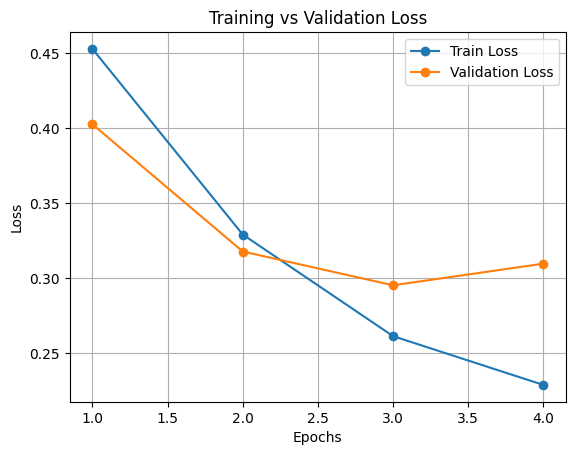

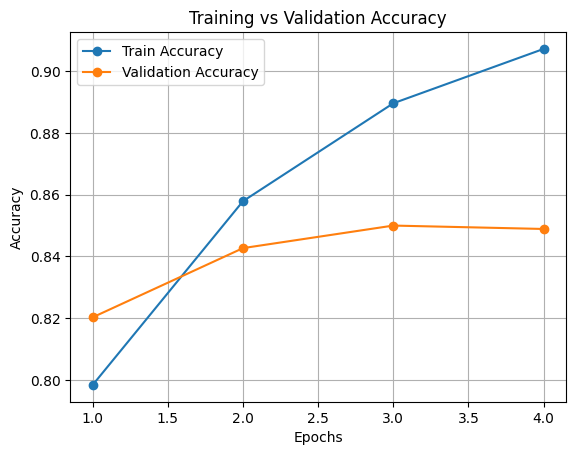

In [4]:
import matplotlib.pyplot as plt

# ---- LOSS CURVE ----
plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()


# ---- ACCURACY CURVE ----
plt.figure()
plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

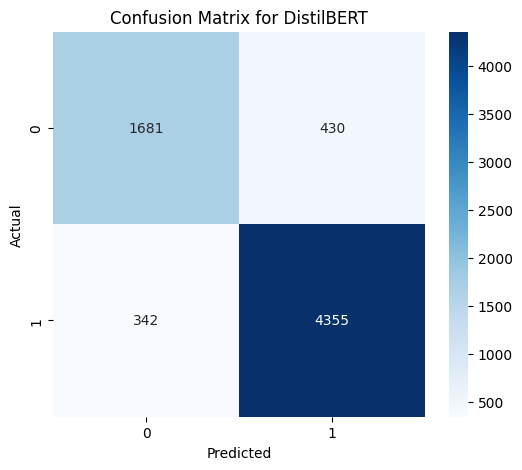

In [5]:
def plot_confusion_matrix(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Testing"):
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Class 0', 'Class 1'],
        yticklabels=['Class 0', 'Class 1']
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for DistilBERT')
    plt.show()

    return all_labels, all_preds

y_true, y_pred = plot_confusion_matrix(model, test_dataloader, device)

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def print_classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary')
    recall = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')

    print("\n📊 Model Performance Metrics")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")


print_classification_metrics(y_true, y_pred)


📊 Model Performance Metrics
Accuracy : 0.8500
Precision: 0.8501
Recall   : 0.8572
F1-score : 0.8536


In [8]:
save_path = "DistilBERT_model"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print("model saved")

model saved


#### To Load Model back


from transformers import DistilBertForSequenceClassification, DistilBertTokenizer

model = DistilBertForSequenceClassification.from_pretrained("DistilBERT_model")
tokenizer = DistilBertTokenizer.from_pretrained("DistilBERT_model")